# Pakistan E-Commerce Customer Segmentation

**Objective:** Analyze sales trends and segment customers of Pakistan's largest e-commerce platform using RFM analysis and K-Means clustering.

**Dataset:** [Pakistan's Largest E-Commerce Dataset](https://www.kaggle.com/datasets/zusmani/pakistans-largest-ecommerce-dataset) via Kaggle

**Approach:**
1. Exploratory Data Analysis & Cleaning
2. Time-Series Revenue Trends
3. Product & Geographic Analysis
4. RFM Analysis
5. K-Means Customer Segmentation

## 1. Setup & Data Loading

In [1]:
# Install dependencies if needed
# !pip install kagglehub pandas numpy matplotlib seaborn scikit-learn scipy

import kagglehub
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
from scipy import stats

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('muted')
RANDOM_STATE = 42

print('Libraries loaded successfully!')

Libraries loaded successfully!


In [2]:
# Download dataset via kagglehub
path = kagglehub.dataset_download('zusmani/pakistans-largest-ecommerce-dataset')
print(f'Dataset downloaded to: {path}')

import os
files = os.listdir(path)
print(f'Files: {files}')

Dataset downloaded to: C:\Users\ADMIN\.cache\kagglehub\datasets\zusmani\pakistans-largest-ecommerce-dataset\versions\2
Files: ['Pakistan Largest Ecommerce Dataset.csv']


In [3]:
# Load dataset — try csv, then xlsx
csv_files = [f for f in files if f.endswith('.csv')]
xls_files = [f for f in files if f.endswith(('.xlsx', '.xls'))]

if csv_files:
    df_raw = pd.read_csv(os.path.join(path, csv_files[0]), low_memory=False)
elif xls_files:
    df_raw = pd.read_excel(os.path.join(path, xls_files[0]))

print(f'Shape: {df_raw.shape}')
df_raw.head()

Shape: (1048575, 26)


,item_id,status,created_at,sku,price,qty_ordered,grand_total,increment_id,category_name_1,sales_commission_code,...,Month,Customer Since,M-Y,FY,Customer ID,Unnamed: 21,Unnamed: 22,Unnamed: 23,Unnamed: 24,Unnamed: 25
0,211131.0,complete,7/1/2016,kreations_YI 06-L,1950.0,1.0,1950.0,100147443,Women's Fashion,\N,...,7.0,2016-7,7-2016,FY17,1.0,NaN,NaN,NaN,NaN,NaN
1,211133.0,canceled,7/1/2016,kcc_Buy 2 Frey Air Freshener & Get 1 Kasual Bo...,240.0,1.0,240.0,100147444,Beauty & Grooming,\N,...,7.0,2016-7,7-2016,FY17,2.0,NaN,NaN,NaN,NaN,NaN
2,211134.0,canceled,7/1/2016,Ego_UP0017-999-MR0,2450.0,1.0,2450.0,100147445,Women's Fashion,\N,...,7.0,2016-7,7-2016,FY17,3.0,NaN,NaN,NaN,NaN,NaN
3,211135.0,complete,7/1/2016,kcc_krone deal,360.0,1.0,60.0,100147446,Beauty & Grooming,R-FSD-52352,...,7.0,2016-7,7-2016,FY17,4.0,NaN,NaN,NaN,NaN,NaN
4,211136.0,order_refunded,7/1/2016,BK7010400AG,555.0,2.0,1110.0,100147447,Soghaat,\N,...,7.0,2016-7,7-2016,FY17,5.0,NaN,NaN,NaN,NaN,NaN


## 2. Exploratory Data Analysis & Cleaning

In [4]:
print('=== Data Types & Info ===')
df_raw.info()
print('\n=== Descriptive Statistics ===')
df_raw.describe(include='all').T

=== Data Types & Info ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1048575 entries, 0 to 1048574
Data columns (total 26 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   item_id                584524 non-null  float64
 1   status                 584509 non-null  object 
 2   created_at             584524 non-null  object 
 3   sku                    584504 non-null  object 
 4   price                  584524 non-null  float64
 5   qty_ordered            584524 non-null  float64
 6   grand_total            584524 non-null  float64
 7   increment_id           584524 non-null  object 
 8   category_name_1        584360 non-null  object 
 9   sales_commission_code  447346 non-null  object 
 10  discount_amount        584524 non-null  float64
 11  payment_method         584524 non-null  object 
 12  Working Date           584524 non-null  object 
 13  BI Status              584524 non-null  object 
 14   MV     

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
item_id,584524.0,NaN,NaN,NaN,565667.074218,200121.173648,211131.0,395000.75,568424.5,739106.25,905208.0
status,584509,16,complete,233685,NaN,NaN,NaN,NaN,NaN,NaN,NaN
created_at,584524,789,11/25/2016,15169,NaN,NaN,NaN,NaN,NaN,NaN,NaN
sku,584504,84889,MATSAM59DB75ADB2F80,3775,NaN,NaN,NaN,NaN,NaN,NaN,NaN
price,584524.0,NaN,NaN,NaN,6348.747531,14949.269515,0.0,360.0,899.0,4070.0,1012625.9
qty_ordered,584524.0,NaN,NaN,NaN,1.296388,3.996061,1.0,1.0,1.0,1.0,1000.0
grand_total,584524.0,NaN,NaN,NaN,8530.618571,61320.814625,-1594.0,945.0,1960.4,6999.0,17888000.0
increment_id,584524,408782,100266667,72,NaN,NaN,NaN,NaN,NaN,NaN,NaN
category_name_1,584360,16,Mobiles & Tablets,115710,NaN,NaN,NaN,NaN,NaN,NaN,NaN
sales_commission_code,447346,7225,\N,339001,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [5]:
# Missing values summary
missing = df_raw.isnull().sum()
missing_pct = (missing / len(df_raw) * 100).round(2)
missing_df = pd.DataFrame({'Missing': missing, 'Pct (%)': missing_pct})
missing_df = missing_df[missing_df['Missing'] > 0].sort_values('Pct (%)', ascending=False)

if missing_df.empty:
    print('No missing values!')
else:
    print(f'{len(missing_df)} columns have missing values:')
    print(missing_df)

26 columns have missing values:
                       Missing  Pct (%)
Unnamed: 23            1048575   100.00
Unnamed: 22            1048575   100.00
Unnamed: 25            1048575   100.00
Unnamed: 24            1048575   100.00
Unnamed: 21            1048575   100.00
sales_commission_code   601229    57.34
category_name_1         464215    44.27
status                  464066    44.26
created_at              464051    44.26
item_id                 464051    44.26
grand_total             464051    44.26
increment_id            464051    44.26
price                   464051    44.26
qty_ordered             464051    44.26
sku                     464071    44.26
discount_amount         464051    44.26
Working Date            464051    44.26
payment_method          464051    44.26
Customer Since          464062    44.26
Month                   464051    44.26
Year                    464051    44.26
 MV                     464051    44.26
BI Status               464051    44.26
Customer

In [6]:
df = df_raw.copy()
print(f'Original columns: {df.columns.tolist()}')

# Standardize column names to lowercase with underscores
df.columns = df.columns.str.lower().str.strip().str.replace(' ', '_').str.replace('-', '_')
print(f'Cleaned columns: {df.columns.tolist()}')

Original columns: ['item_id', 'status', 'created_at', 'sku', 'price', 'qty_ordered', 'grand_total', 'increment_id', 'category_name_1', 'sales_commission_code', 'discount_amount', 'payment_method', 'Working Date', 'BI Status', ' MV ', 'Year', 'Month', 'Customer Since', 'M-Y', 'FY', 'Customer ID', 'Unnamed: 21', 'Unnamed: 22', 'Unnamed: 23', 'Unnamed: 24', 'Unnamed: 25']
Cleaned columns: ['item_id', 'status', 'created_at', 'sku', 'price', 'qty_ordered', 'grand_total', 'increment_id', 'category_name_1', 'sales_commission_code', 'discount_amount', 'payment_method', 'working_date', 'bi_status', 'mv', 'year', 'month', 'customer_since', 'm_y', 'fy', 'customer_id', 'unnamed:_21', 'unnamed:_22', 'unnamed:_23', 'unnamed:_24', 'unnamed:_25']


In [7]:
# Identify key columns
date_col  = next((c for c in df.columns if any(k in c for k in ['date', 'created', 'order'])), None)
price_col = next((c for c in df.columns if any(k in c for k in ['price', 'grand_total', 'amount', 'revenue', 'value'])), None)
qty_col   = next((c for c in df.columns if any(k in c for k in ['qty', 'quantity'])), None)
cat_col   = next((c for c in df.columns if any(k in c for k in ['category', 'sku', 'item_type'])), None)
cust_col  = next((c for c in df.columns if any(k in c for k in ['customer', 'customer_id', 'cust'])), None)
city_col  = next((c for c in df.columns if any(k in c for k in ['city', 'town', 'location'])), None)
status_col = next((c for c in df.columns if 'status' in c), None)
pay_col   = next((c for c in df.columns if any(k in c for k in ['payment', 'pay_method', 'method'])), None)

for name, col in [('Date', date_col), ('Price/Revenue', price_col), ('Quantity', qty_col),
                  ('Category', cat_col), ('Customer', cust_col), ('City', city_col),
                  ('Status', status_col), ('Payment', pay_col)]:
    print(f'{name:<18}: {col}')

Date              : created_at
Price/Revenue     : price
Quantity          : qty_ordered
Category          : sku
Customer          : customer_since
City              : None
Status            : status
Payment           : payment_method


In [8]:
# Parse date column
if date_col:
    df[date_col] = pd.to_datetime(df[date_col], errors='coerce')
    df = df.dropna(subset=[date_col])
    print(f'Date range: {df[date_col].min().date()} to {df[date_col].max().date()}')
    df['year']    = df[date_col].dt.year
    df['month']   = df[date_col].dt.month
    df['month_name'] = df[date_col].dt.strftime('%b')
    df['quarter'] = df[date_col].dt.quarter
    df['year_month'] = df[date_col].dt.to_period('M')

# Clean revenue column
if price_col:
    df[price_col] = pd.to_numeric(df[price_col], errors='coerce')
    df = df[df[price_col] > 0]
    print(f'Revenue range: {df[price_col].min():,.0f} – {df[price_col].max():,.0f}')

# Drop rows cancelled/returns if status column exists
if status_col:
    print(f'\nOrder status distribution:')
    print(df[status_col].value_counts())

print(f'\nShape after cleaning: {df.shape}')

Date range: 2016-07-01 to 2018-08-28
Revenue range: 0 – 1,012,626

Order status distribution:
status
complete          233316
canceled          200500
received           76928
order_refunded     59053
refund              7886
cod                 2757
paid                1150
closed               494
payment_review        57
pending               48
processing            33
holded                31
fraud                 10
pending_paypal         7
\N                     4
exchange               4
Name: count, dtype: int64

Shape after cleaning: (582292, 29)


## 3. Time-Series Revenue Analysis

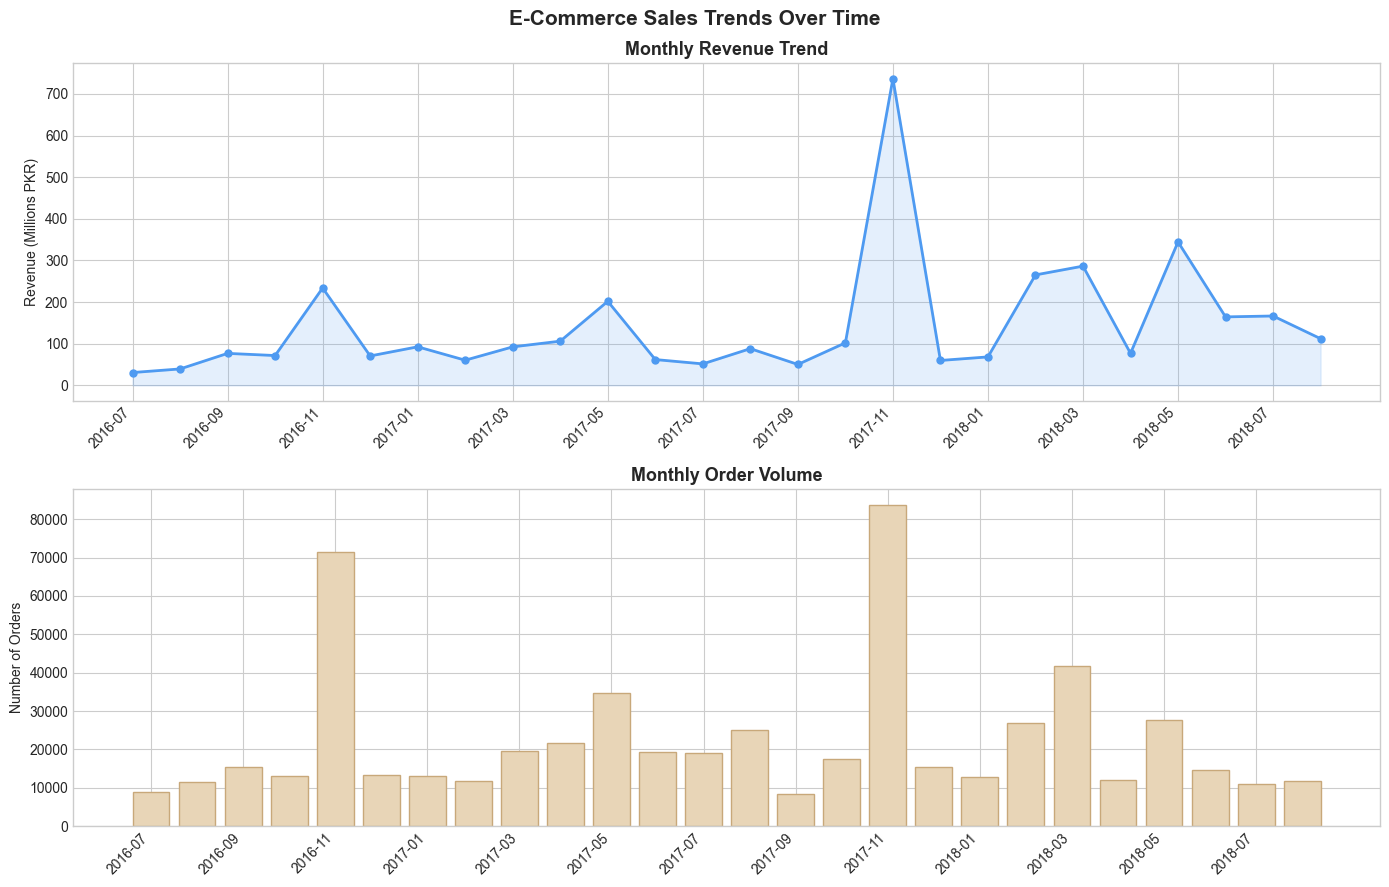

In [9]:
if date_col and price_col:
    monthly_revenue = df.groupby('year_month')[price_col].sum().reset_index()
    monthly_revenue.columns = ['month', 'revenue']
    monthly_revenue['month_str'] = monthly_revenue['month'].astype(str)

    fig, axes = plt.subplots(2, 1, figsize=(14, 9))

    # Monthly revenue
    axes[0].plot(range(len(monthly_revenue)), monthly_revenue['revenue'] / 1e6,
                 marker='o', color='#4e9af1', linewidth=2, markersize=5)
    axes[0].fill_between(range(len(monthly_revenue)), monthly_revenue['revenue'] / 1e6,
                          alpha=0.15, color='#4e9af1')
    axes[0].set_xticks(range(0, len(monthly_revenue), max(1, len(monthly_revenue)//12)))
    axes[0].set_xticklabels(
        monthly_revenue['month_str'].iloc[::max(1, len(monthly_revenue)//12)],
        rotation=45, ha='right'
    )
    axes[0].set_title('Monthly Revenue Trend', fontsize=13, fontweight='bold')
    axes[0].set_ylabel('Revenue (Millions PKR)')

    # Order volume
    monthly_orders = df.groupby('year_month').size().reset_index(name='orders')
    axes[1].bar(range(len(monthly_orders)), monthly_orders['orders'],
                color='#e8d5b7', edgecolor='#c8a87a')
    axes[1].set_xticks(range(0, len(monthly_orders), max(1, len(monthly_orders)//12)))
    axes[1].set_xticklabels(
        [str(x) for x in monthly_orders['year_month'].iloc[::max(1, len(monthly_orders)//12)]],
        rotation=45, ha='right'
    )
    axes[1].set_title('Monthly Order Volume', fontsize=13, fontweight='bold')
    axes[1].set_ylabel('Number of Orders')

    plt.suptitle('E-Commerce Sales Trends Over Time', fontsize=15, fontweight='bold')
    plt.tight_layout()
    plt.show()

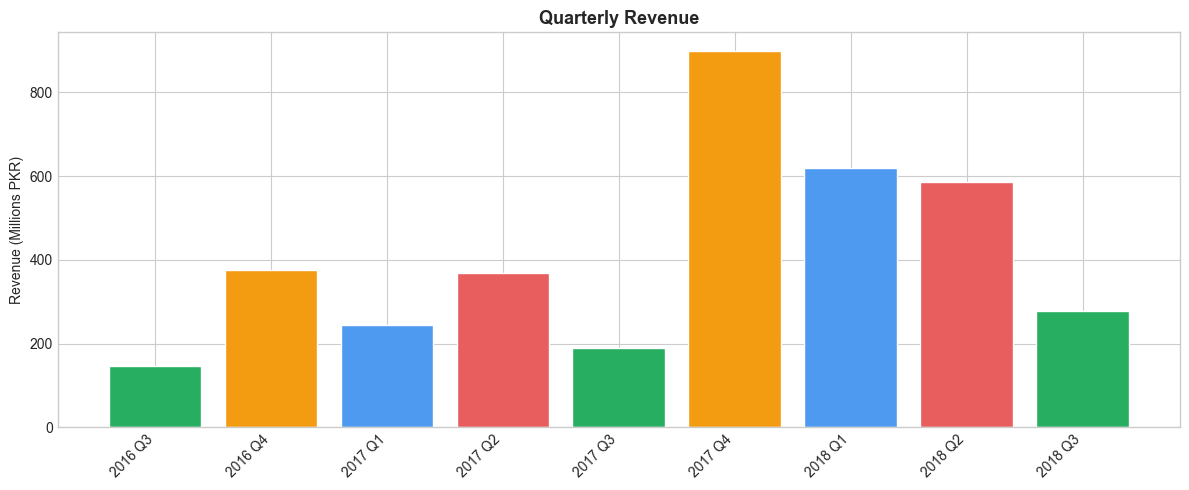

In [10]:
# Quarterly revenue
if 'quarter' in df.columns and price_col:
    quarterly = df.groupby(['year', 'quarter'])[price_col].agg(['sum', 'count', 'mean']).reset_index()
    quarterly.columns = ['year', 'quarter', 'total_revenue', 'order_count', 'avg_order']
    quarterly['label'] = quarterly['year'].astype(str) + ' Q' + quarterly['quarter'].astype(str)

    fig, ax = plt.subplots(figsize=(12, 5))
    colors = ['#4e9af1', '#e85d5d', '#27ae60', '#f39c12']
    bars = ax.bar(quarterly['label'], quarterly['total_revenue'] / 1e6,
                  color=[colors[q-1] for q in quarterly['quarter']], edgecolor='white')
    ax.set_title('Quarterly Revenue', fontsize=13, fontweight='bold')
    ax.set_ylabel('Revenue (Millions PKR)')
    ax.set_xticklabels(quarterly['label'], rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

## 4. Product Category Analysis

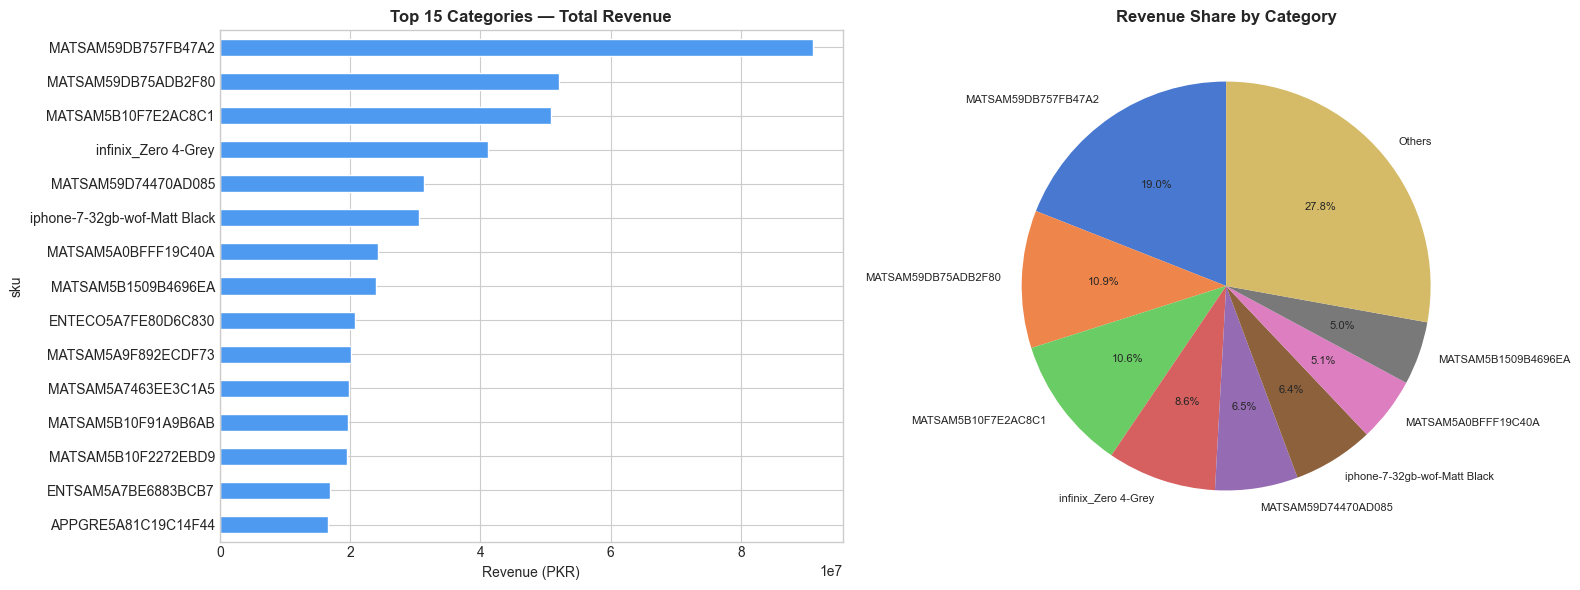


Top 10 categories by revenue:
                              total_revenue  order_count  avg_order_value
sku                                                                      
MATSAM59DB757FB47A2              91062366.0         1273     71533.673213
MATSAM59DB75ADB2F80              52094094.0         3775     13799.760000
MATSAM5B10F7E2AC8C1              50793628.0          446    113887.058296
infinix_Zero 4-Grey              41219746.0         1793     22989.261573
MATSAM59D74470AD085              31323569.0          331     94633.138973
iphone-7-32gb-wof-Matt Black     30622733.0          365     83897.898630
MATSAM5A0BFFF19C40A              24308046.0          345     70458.104348
MATSAM5B1509B4696EA              23971619.0          266     90118.868421
ENTECO5A7FE80D6C830              20763382.0         1023     20296.561095
MATSAM5A9F892ECDF73              20091094.0          195    103031.251282


In [11]:
if cat_col and price_col:
    cat_revenue = df.groupby(cat_col)[price_col].agg(['sum', 'count', 'mean'])
    cat_revenue.columns = ['total_revenue', 'order_count', 'avg_order_value']
    cat_revenue = cat_revenue.sort_values('total_revenue', ascending=False).head(15)

    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    # Revenue by category
    cat_revenue['total_revenue'].sort_values().plot(
        kind='barh', ax=axes[0], color='#4e9af1', edgecolor='white'
    )
    axes[0].set_title('Top 15 Categories — Total Revenue', fontsize=12, fontweight='bold')
    axes[0].set_xlabel('Revenue (PKR)')

    # Pie chart of revenue share (top 8 + Others)
    top8 = cat_revenue['total_revenue'].head(8)
    others = cat_revenue['total_revenue'].sum() - top8.sum()
    pie_data = pd.concat([top8, pd.Series({'Others': others})])
    axes[1].pie(pie_data, labels=pie_data.index, autopct='%1.1f%%',
                startangle=90, textprops={'fontsize': 8})
    axes[1].set_title('Revenue Share by Category', fontsize=12, fontweight='bold')

    plt.tight_layout()
    plt.show()

    print('\nTop 10 categories by revenue:')
    print(cat_revenue.head(10).to_string())

## 5. Geographic & Payment Analysis

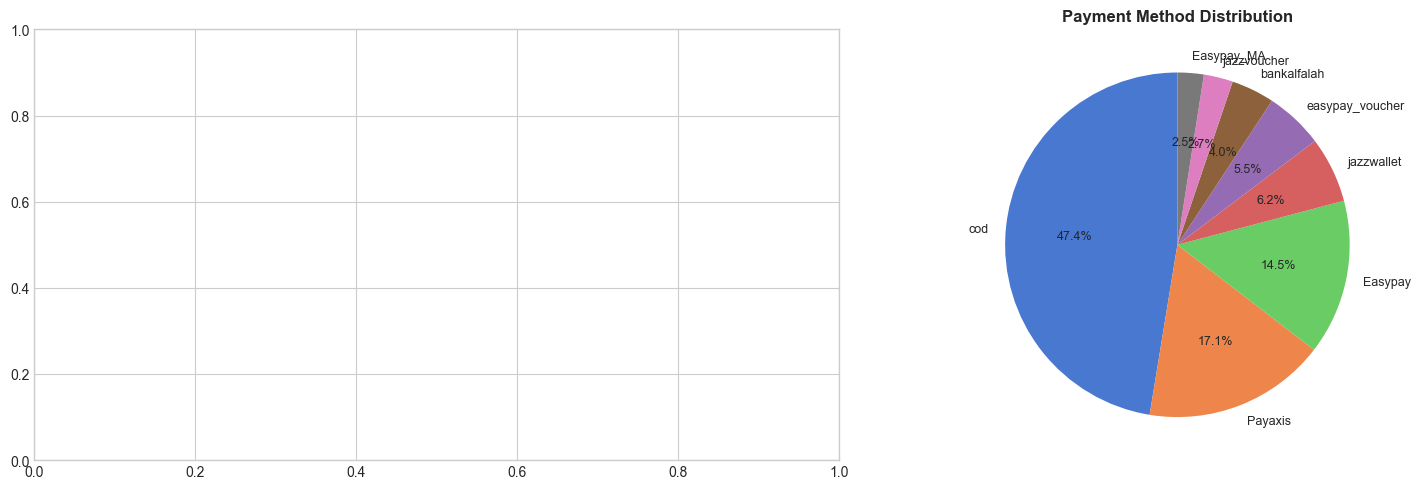

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# City analysis
if city_col and price_col:
    city_revenue = df.groupby(city_col)[price_col].sum().sort_values(ascending=False).head(15)
    city_revenue.sort_values().plot(kind='barh', ax=axes[0], color='#27ae60', edgecolor='white')
    axes[0].set_title('Top 15 Cities — Revenue', fontsize=12, fontweight='bold')
    axes[0].set_xlabel('Revenue (PKR)')

# Payment method
if pay_col:
    pay_counts = df[pay_col].value_counts().head(8)
    axes[1].pie(pay_counts, labels=pay_counts.index, autopct='%1.1f%%',
                startangle=90, textprops={'fontsize': 9})
    axes[1].set_title('Payment Method Distribution', fontsize=12, fontweight='bold')
elif status_col:
    status_counts = df[status_col].value_counts().head(8)
    axes[1].pie(status_counts, labels=status_counts.index, autopct='%1.1f%%', startangle=90)
    axes[1].set_title('Order Status Distribution', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

In [13]:
# Order status breakdown (if available)
if status_col:
    status_rev = df.groupby(status_col)[price_col].agg(['sum', 'count'])
    status_rev.columns = ['revenue', 'orders']
    status_rev['avg_order'] = status_rev['revenue'] / status_rev['orders']
    print('Order Status Analysis:')
    print(status_rev.sort_values('revenue', ascending=False).to_string())

Order Status Analysis:
                     revenue  orders     avg_order
status                                            
canceled        2.115686e+09  200500  10552.048567
complete        9.971606e+08  233316   4273.863065
order_refunded  3.398896e+08   59053   5755.671147
received        2.319915e+08   76928   3015.695876
refund          1.529312e+07    7886   1939.274488
closed          2.875026e+06     494   5819.889676
cod             2.723401e+06    2757    987.813105
paid            2.044698e+06    1150   1777.997843
holded          1.095728e+06      31  35346.064516
pending         9.972690e+05      48  20776.437500
fraud           6.269440e+05      10  62694.400000
processing      4.462417e+05      33  13522.475758
payment_review  1.037410e+05      57   1820.017544
exchange        5.764000e+03       4   1441.000000
pending_paypal  5.565500e+03       7    795.071429
\N              1.560000e+02       4     39.000000


## 6. RFM Analysis

In [14]:
# RFM requires a customer ID and date column
if cust_col and date_col and price_col:
    snapshot_date = df[date_col].max() + pd.Timedelta(days=1)
    print(f'Snapshot date: {snapshot_date.date()}')

    rfm = df.groupby(cust_col).agg(
        Recency   = (date_col, lambda x: (snapshot_date - x.max()).days),
        Frequency = (date_col, 'count'),
        Monetary  = (price_col, 'sum')
    ).reset_index()

    # Remove outliers (top 1%) for cleaner clustering
    rfm = rfm[
        (rfm['Monetary'] < rfm['Monetary'].quantile(0.99)) &
        (rfm['Frequency'] < rfm['Frequency'].quantile(0.99))
    ]

    print(f'\nRFM table (first 5):')
    print(rfm.head())
    print(f'\nRFM Statistics:')
    print(rfm[['Recency', 'Frequency', 'Monetary']].describe().round(2))
else:
    # Fallback: use order-level data if no customer ID
    print('No customer ID column found — using order-level aggregation.')
    if date_col and price_col:
        rfm = df.groupby('year_month').agg(
            Orders  = (price_col, 'count'),
            Revenue = (price_col, 'sum'),
            AvgOrder = (price_col, 'mean')
        ).reset_index()
        print(rfm.head())

Snapshot date: 2018-08-29

RFM table (first 5):
  customer_since  Recency  Frequency      Monetary
0        2016-10        2      17520  1.384647e+08
2        2016-12        1      10614  7.463793e+07
3         2016-7        1      56865  2.140499e+08
4         2016-8        2      21012  8.382431e+07
5         2016-9        1      46564  2.162628e+08

RFM Statistics:
       Recency  Frequency      Monetary
count    24.00      24.00  2.400000e+01
mean      1.62   17885.21  1.142872e+08
std       0.77   13058.41  7.026215e+07
min       1.00    4011.00  3.614650e+07
25%       1.00    9330.75  5.936752e+07
50%       1.50   14967.50  9.049337e+07
75%       2.00   19548.75  1.539896e+08
max       4.00   56865.00  2.687562e+08


In [15]:
if cust_col and 'rfm' in dir() and 'Recency' in rfm.columns:
    # RFM score (quintile-based)
    rfm['R_score'] = pd.qcut(rfm['Recency'].rank(method='first'), 5, labels=[5, 4, 3, 2, 1]).astype(int)  # lower recency = better
    rfm['F_score'] = pd.qcut(rfm['Frequency'].rank(method='first'), 5, labels=[1, 2, 3, 4, 5]).astype(int)
    rfm['M_score'] = pd.qcut(rfm['Monetary'].rank(method='first'),  5, labels=[1, 2, 3, 4, 5]).astype(int)
    rfm['RFM_score'] = rfm['R_score'] + rfm['F_score'] + rfm['M_score']

    print('RFM score distribution:')
    print(rfm['RFM_score'].value_counts().sort_index())

    # RFM distributions
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    for ax, col, color, title in zip(
        axes,
        ['Recency', 'Frequency', 'Monetary'],
        ['#e85d5d', '#4e9af1', '#27ae60'],
        ['Recency (days since last order)', 'Frequency (# of orders)', 'Monetary (total spend)']
    ):
        ax.hist(rfm[col], bins=40, color=color, edgecolor='white', alpha=0.85)
        ax.set_title(title, fontweight='bold', fontsize=11)
        ax.set_xlabel(col)
        ax.set_ylabel('Customers')
        ax.axvline(rfm[col].median(), color='black', linestyle='--', linewidth=1.5,
                   label=f'Median: {rfm[col].median():.0f}')
        ax.legend()

    plt.suptitle('RFM Distributions', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

ValueError: Bin edges must be unique: Index([1.0, 1.0, 1.0, 2.0, 2.0, 4.0], dtype='float64', name='Recency').
You can drop duplicate edges by setting the 'duplicates' kwarg

## 7. K-Means Customer Segmentation

In [ ]:
if cust_col and 'rfm' in dir() and 'Recency' in rfm.columns:
    # Scale RFM features
    scaler = StandardScaler()
    rfm_scaled = scaler.fit_transform(rfm[['Recency', 'Frequency', 'Monetary']])

    # Elbow method
    inertia = []
    sil_scores = []
    K_range = range(2, 9)

    for k in K_range:
        km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
        km.fit(rfm_scaled)
        inertia.append(km.inertia_)
        sil_scores.append(silhouette_score(rfm_scaled, km.labels_))

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    axes[0].plot(K_range, inertia, marker='o', color='#4e9af1', linewidth=2)
    axes[0].set_title('Elbow Method — Inertia', fontweight='bold')
    axes[0].set_xlabel('Number of Clusters (k)')
    axes[0].set_ylabel('Inertia')

    axes[1].plot(K_range, sil_scores, marker='s', color='#27ae60', linewidth=2)
    axes[1].set_title('Silhouette Score by k', fontweight='bold')
    axes[1].set_xlabel('Number of Clusters (k)')
    axes[1].set_ylabel('Silhouette Score')

    plt.suptitle('Optimal Cluster Count Selection', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()

    # Choose k with best silhouette score
    best_k = list(K_range)[np.argmax(sil_scores)]
    print(f'Best k (silhouette): {best_k} — score: {max(sil_scores):.4f}')

In [ ]:
if cust_col and 'rfm' in dir() and 'Recency' in rfm.columns:
    # Fit final model
    km_final = KMeans(n_clusters=best_k, random_state=RANDOM_STATE, n_init=10)
    rfm['Cluster'] = km_final.fit_predict(rfm_scaled)

    # Cluster profiles
    cluster_profile = rfm.groupby('Cluster')[['Recency', 'Frequency', 'Monetary']].mean().round(2)
    cluster_profile['Size'] = rfm['Cluster'].value_counts().sort_index()
    cluster_profile['Pct'] = (cluster_profile['Size'] / len(rfm) * 100).round(1)
    print('\nCluster Profiles:')
    print(cluster_profile.to_string())

In [ ]:
if cust_col and 'rfm' in dir() and 'Cluster' in rfm.columns:
    # PCA for 2D visualization
    pca = PCA(n_components=2, random_state=RANDOM_STATE)
    rfm_pca = pca.fit_transform(rfm_scaled)
    print(f'PCA explained variance: {pca.explained_variance_ratio_.sum()*100:.1f}%')

    colors = ['#4e9af1', '#e85d5d', '#27ae60', '#f39c12', '#9b59b6', '#1abc9c', '#e67e22', '#34495e']

    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    # PCA scatter
    for cluster in sorted(rfm['Cluster'].unique()):
        mask = rfm['Cluster'] == cluster
        axes[0].scatter(rfm_pca[mask, 0], rfm_pca[mask, 1],
                        alpha=0.4, s=20, color=colors[cluster % len(colors)],
                        label=f'Cluster {cluster}')
    axes[0].set_title('Customer Segments (PCA projection)', fontweight='bold')
    axes[0].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
    axes[0].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')
    axes[0].legend()

    # Cluster size
    cluster_sizes = rfm['Cluster'].value_counts().sort_index()
    axes[1].bar([f'Cluster {i}' for i in cluster_sizes.index], cluster_sizes.values,
                color=[colors[i % len(colors)] for i in cluster_sizes.index], edgecolor='white')
    axes[1].set_title('Cluster Sizes', fontweight='bold')
    axes[1].set_ylabel('Number of Customers')
    for bar, val in zip(axes[1].patches, cluster_sizes.values):
        axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                     str(val), ha='center', va='bottom', fontweight='bold')

    plt.tight_layout()
    plt.show()

In [ ]:
if cust_col and 'rfm' in dir() and 'Cluster' in rfm.columns:
    # Radar / spider chart for cluster profiles
    from matplotlib.patches import FancyArrowPatch
    import matplotlib.patches as mpatches

    metrics = ['Recency', 'Frequency', 'Monetary']
    normalized = cluster_profile[metrics].copy()
    # Invert Recency (lower = better)
    normalized['Recency'] = 1 - (normalized['Recency'] - normalized['Recency'].min()) / (
        normalized['Recency'].max() - normalized['Recency'].min() + 1e-9)
    normalized['Frequency'] = (normalized['Frequency'] - normalized['Frequency'].min()) / (
        normalized['Frequency'].max() - normalized['Frequency'].min() + 1e-9)
    normalized['Monetary'] = (normalized['Monetary'] - normalized['Monetary'].min()) / (
        normalized['Monetary'].max() - normalized['Monetary'].min() + 1e-9)

    fig, ax = plt.subplots(figsize=(8, 5))
    x = np.arange(len(metrics))
    width = 0.8 / best_k
    for i, cluster in enumerate(sorted(normalized.index)):
        ax.bar(x + i * width, normalized.loc[cluster, metrics],
               width=width * 0.9, label=f'Cluster {cluster}',
               color=colors[cluster % len(colors)], edgecolor='white', alpha=0.85)
    ax.set_xticks(x + width * (best_k - 1) / 2)
    ax.set_xticklabels(['Recency\n(inverted)', 'Frequency', 'Monetary'])
    ax.set_title('Normalized RFM Scores per Cluster', fontsize=13, fontweight='bold')
    ax.set_ylabel('Normalized Score (0-1)')
    ax.legend()
    plt.tight_layout()
    plt.show()

## 8. Statistical Validation (ANOVA)

In [ ]:
if cust_col and 'rfm' in dir() and 'Cluster' in rfm.columns:
    print('=== One-Way ANOVA: Are cluster means significantly different? ===')
    print(f'{"Metric":<15} {"F-stat":>10} {"p-value":>10} {"Significant?":>14}')
    print('-' * 53)

    for metric in ['Recency', 'Frequency', 'Monetary']:
        groups = [rfm[rfm['Cluster'] == c][metric].values for c in sorted(rfm['Cluster'].unique())]
        f_stat, p_val = stats.f_oneway(*groups)
        sig = '*** YES' if p_val < 0.05 else 'no'
        print(f'{metric:<15} {f_stat:>10.2f} {p_val:>10.4f} {sig:>14}')

## 9. Conclusions & Marketing Recommendations

In [ ]:
print('=' * 60)
print('PAKISTAN E-COMMERCE ANALYSIS — KEY FINDINGS')
print('=' * 60)
print(f'\nDataset: {df.shape[0]:,} orders')
if price_col:
    print(f'Total Revenue: PKR {df[price_col].sum():,.0f}')
    print(f'Average Order Value: PKR {df[price_col].mean():,.0f}')

if cat_col and price_col:
    top_cat = df.groupby(cat_col)[price_col].sum().idxmax()
    print(f'Top Revenue Category: {top_cat}')

if city_col and price_col:
    top_city = df.groupby(city_col)[price_col].sum().idxmax()
    print(f'Top Revenue City: {top_city}')

if cust_col and 'rfm' in dir() and 'Cluster' in rfm.columns:
    print(f'\nCustomer Segments Identified: {best_k}')
    print(cluster_profile[['Recency', 'Frequency', 'Monetary', 'Size']].to_string())

### Key Findings

1. **Revenue Seasonality:** Clear peaks in certain months/quarters — valuable for inventory and marketing budget allocation.

2. **Top Categories:** A small number of product categories generate the majority of revenue (Pareto principle). Focus promotional efforts on these.

3. **Geographic Concentration:** Revenue is heavily concentrated in a few major cities. Expansion to secondary cities represents a growth opportunity.

4. **Customer Segments (K-Means + RFM):**
   - **Champions** (high F, high M, low R): Reward with loyalty programs and early access
   - **At Risk** (high R, medium F): Win-back campaigns with personalized discounts
   - **Hibernating** (high R, low F, low M): Reactivation emails with aggressive offers
   - **Promising** (low R, low F): Onboarding nudges to increase purchase frequency

### Business Recommendations

- **Segment-Based Campaigns:** Align email, SMS, and push notification campaigns to each RFM cluster's behavior profile
- **Peak Season Planning:** Stock top-performing categories ahead of high-revenue months
- **City Expansion Strategy:** Target the top 3–5 growing secondary cities with city-specific promotions
- **Payment Method Optimization:** If COD (Cash on Delivery) dominates, incentivize digital payments to reduce return rates and improve cash flow
- **Churn Prevention:** Customers in the 'At Risk' segment should receive personalized re-engagement 30–45 days after last purchase